## Week 1 Practice
----
- **Dataset: MNIST, CIFAR-10**
  - if use torchvision.datasets:
  - https://docs.pytorch.org/vision/stable/datasets.html
  - if use **Custom Dataset**:
  - https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
- **Model: Freely Select from torchvision library (e.g., VGG, ResNet)**
  - https://docs.pytorch.org/vision/main/models.html
- **Goal: Achieve over 80% accuracy on the test data**
  
*Env(cs231n_311): Python==3.11 | pytorch(CUDA 12.6) | torchvision | 

In [23]:
# [Import tools for custom datasets and models]
# Not to use 'from torchvision.datasets import MNIST, CIFAR10', Download Original Datasets and Make Custom Datasets
import os
import pandas as pd
import pickle
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import decode_image
import torchvision.transforms as transforms

from torchvision.models import resnet18, resnet50, resnet101 
from torchvision.models import vgg16, vgg19

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [4]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

### Datasets

#### MNIST
**[Files]**
- http://yann.lecun.com/exdb/mnist/ (Not Exist?)
- https://www.kaggle.com/datasets/hojjatk/mnist-dataset 

**[Structure]**
- size: totally 70000 images; 60000 for train, 10000 for test
- images: 28x28 byte = 784 byte
- labels: 1 byte

#### CIFAR-10
**[Files]**
- https://www.cs.toronto.edu/~kriz/cifar.html

**[Structure]**
- size: totally 60000 images; 50000 for train, 10000 for test
  - *So, each data batch has 10000 images*
- 3x32x32 color images and labels as a dictionary form (need to unpickle)

### Check the Datasets

#### MNIST

In [37]:
with open('MNIST/train-images.idx3-ubyte', 'rb') as f:
    images = np.frombuffer(f.read(), dtype=np.uint8, offset=16).reshape(-1, 28, 28)

with open('MNIST/train-labels.idx1-ubyte', 'rb') as f:
    labels = np.frombuffer(f.read(), dtype=np.uint8, offset=8)

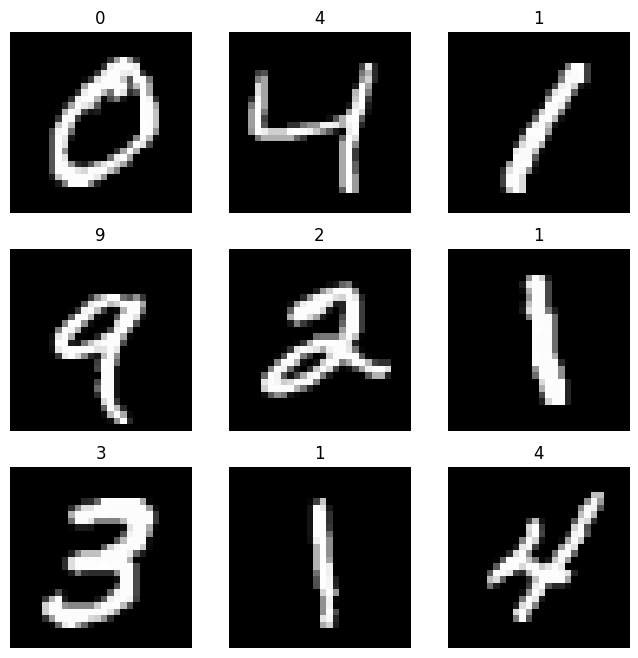

In [38]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    figure.add_subplot(rows, cols, i)
    plt.title(labels[i])
    plt.axis('off')
    plt.imshow(images[i], cmap='gray')

plt.show()

#### CIFAR-10

In [35]:
CIFAR_meta = unpickle('CIFAR-10/batches.meta') 
label_names = CIFAR_meta[b'label_names']

for i in range(10):
    print('label '+ str(i) + ' = ' + label_names[i].decode('utf-8'))

label 0 = airplane
label 1 = automobile
label 2 = bird
label 3 = cat
label 4 = deer
label 5 = dog
label 6 = frog
label 7 = horse
label 8 = ship
label 9 = truck


In [32]:
CIFAR_batches = []

for i in range(1, 6):
    batch = unpickle(f'CIFAR-10/data_batch_{i}')
    CIFAR_batches.append(batch)

CIFAR_test = unpickle('CIFAR-10/test_batch')


C:\Users\teoju\AppData\Local\Temp\ipykernel_12716\321559445.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [34]:
CIFAR_batches[0]

{b'batch_label': b'training batch 1 of 5',
 b'labels': [6,
  9,
  9,
  4,
  1,
  1,
  2,
  7,
  8,
  3,
  4,
  7,
  7,
  2,
  9,
  9,
  9,
  3,
  2,
  6,
  4,
  3,
  6,
  6,
  2,
  6,
  3,
  5,
  4,
  0,
  0,
  9,
  1,
  3,
  4,
  0,
  3,
  7,
  3,
  3,
  5,
  2,
  2,
  7,
  1,
  1,
  1,
  2,
  2,
  0,
  9,
  5,
  7,
  9,
  2,
  2,
  5,
  2,
  4,
  3,
  1,
  1,
  8,
  2,
  1,
  1,
  4,
  9,
  7,
  8,
  5,
  9,
  6,
  7,
  3,
  1,
  9,
  0,
  3,
  1,
  3,
  5,
  4,
  5,
  7,
  7,
  4,
  7,
  9,
  4,
  2,
  3,
  8,
  0,
  1,
  6,
  1,
  1,
  4,
  1,
  8,
  3,
  9,
  6,
  6,
  1,
  8,
  5,
  2,
  9,
  9,
  8,
  1,
  7,
  7,
  0,
  0,
  6,
  9,
  1,
  2,
  2,
  9,
  2,
  6,
  6,
  1,
  9,
  5,
  0,
  4,
  7,
  6,
  7,
  1,
  8,
  1,
  1,
  2,
  8,
  1,
  3,
  3,
  6,
  2,
  4,
  9,
  9,
  5,
  4,
  3,
  6,
  7,
  4,
  6,
  8,
  5,
  5,
  4,
  3,
  1,
  8,
  4,
  7,
  6,
  0,
  9,
  5,
  1,
  3,
  8,
  2,
  7,
  5,
  3,
  4,
  1,
  5,
  7,
  0,
  4,
  7,
  5,
  5,
  1,
  0,
  9,
  6,
  9,
 

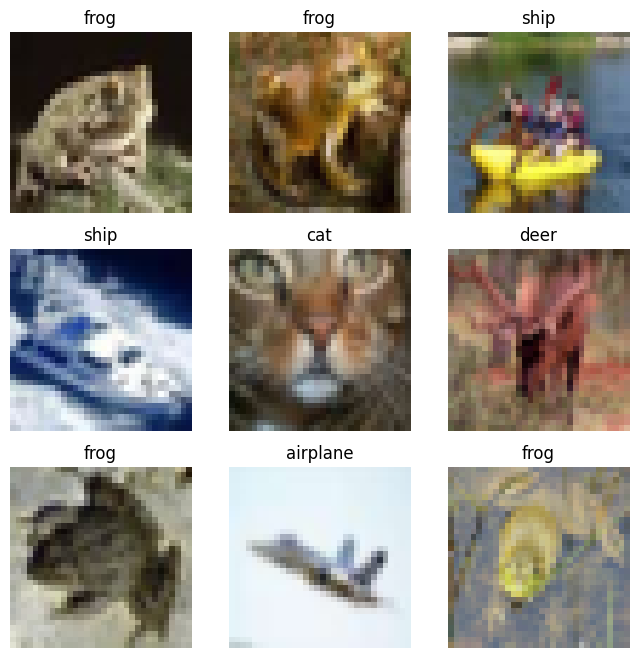

In [33]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
training_data = CIFAR_batches[1]

for i in range(1, cols * rows + 1):
    img, label = training_data[b'data'][i], training_data[b'labels'][i]
    figure.add_subplot(rows, cols, i)

    plt.title(label_names[label].decode('utf-8'))
    plt.axis("off")
    plt.imshow(img.reshape(3, 32, 32).transpose(1, 2, 0)) 
    # transpose로 matplotlib이 인식하는 형태로 변경: Channel 뒤로 빼기

plt.show()

### Custom Dataset (Class)
- https://docs.pytorch.org/vision/stable/datasets.html
- Parent: Pytorch Dataset Class
- Child: Custom Class

#### MNIST

In [ ]:
class MNIST_Dataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file) #path 수정
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

#### CIFAR-10

In [ ]:
class CIFAR_Dataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label